# Spaceship Titanic - Kaggle Competition

**Goal**: Predict which passengers were transported to an alternate dimension

This notebook includes:
- Exploratory Data Analysis
- Feature Engineering
- Model Training: XGBoost, LightGBM, Logistic Regression
- Hyperparameter Optimization with Optuna + CV
- Submission File Generation

## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
from sklearn.linear_model import LogisticRegression

import xgboost as xgb
import lightgbm as lgb

import optuna
from optuna.samplers import TPESampler

import mlflow

import warnings
warnings.filterwarnings('ignore')

# Set random seed
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Libraries imported successfully!")

Libraries imported successfully!


## 2. Load Data

In [2]:
# Load training data
train_df = pd.read_csv('train.csv')

print(f"Training data shape: {train_df.shape}")
print(f"\nFirst few rows:")
train_df.head()

Training data shape: (8693, 14)

First few rows:


,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


In [3]:
# Data info
print("Dataset Info:")
print(train_df.info())
print("\nMissing Values:")
print(train_df.isnull().sum())
print("\nTarget Distribution:")
print(train_df['Transported'].value_counts())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   object 
 1   HomePlanet    8492 non-null   object 
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   object 
 4   Destination   8511 non-null   object 
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   object 
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(7)
memory usage: 891.5+ KB
None

Missing Values:
PassengerId       0
HomePlanet      201
CryoSleep       217
Cabin           199
Destination     182
Age   

In [4]:
# Statistical summary
train_df.describe()

,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
count,8514.000000,8512.000000,8510.000000,8485.000000,8510.000000,8505.000000
mean,28.827930,224.687617,458.077203,173.729169,311.138778,304.854791
std,14.489021,666.717663,1611.489240,604.696458,1136.705535,1145.717189
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,19.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,38.000000,47.000000,76.000000,27.000000,59.000000,46.000000
max,79.000000,14327.000000,29813.000000,23492.000000,22408.000000,24133.000000


## 3. Exploratory Data Analysis

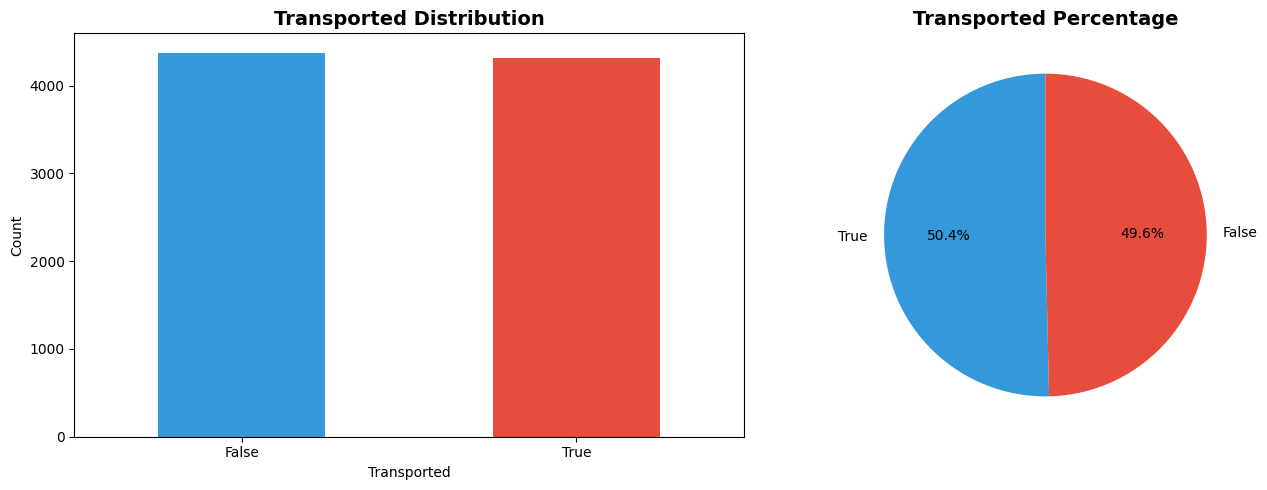

In [5]:
# Target distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
train_df['Transported'].value_counts().plot(kind='bar', ax=axes[0], color=['#3498db', '#e74c3c'])
axes[0].set_title('Transported Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Transported')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(['False', 'True'], rotation=0)

# Pie chart
train_df['Transported'].value_counts().plot(kind='pie', ax=axes[1], autopct='%1.1f%%', 
                                             colors=['#3498db', '#e74c3c'], startangle=90)
axes[1].set_title('Transported Percentage', fontsize=14, fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

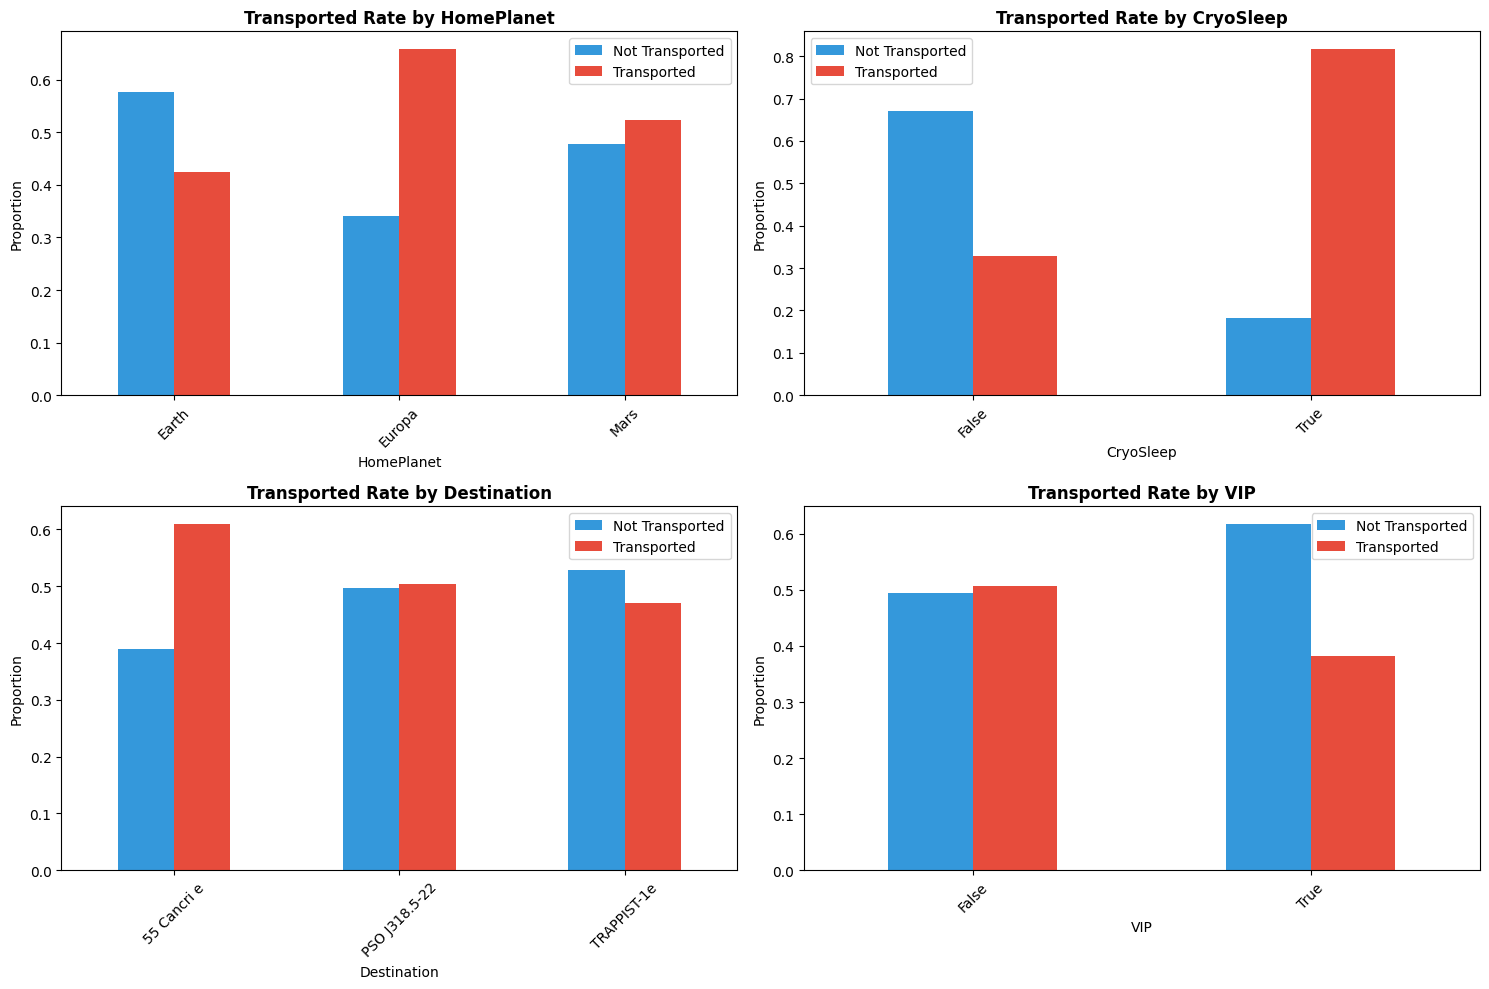

In [6]:
# Categorical features analysis
categorical_features = ['HomePlanet', 'CryoSleep', 'Destination', 'VIP']

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.ravel()

for idx, col in enumerate(categorical_features):
    pd.crosstab(train_df[col], train_df['Transported'], normalize='index').plot(
        kind='bar', ax=axes[idx], color=['#3498db', '#e74c3c']
    )
    axes[idx].set_title(f'Transported Rate by {col}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Proportion')
    axes[idx].legend(['Not Transported', 'Transported'])
    axes[idx].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

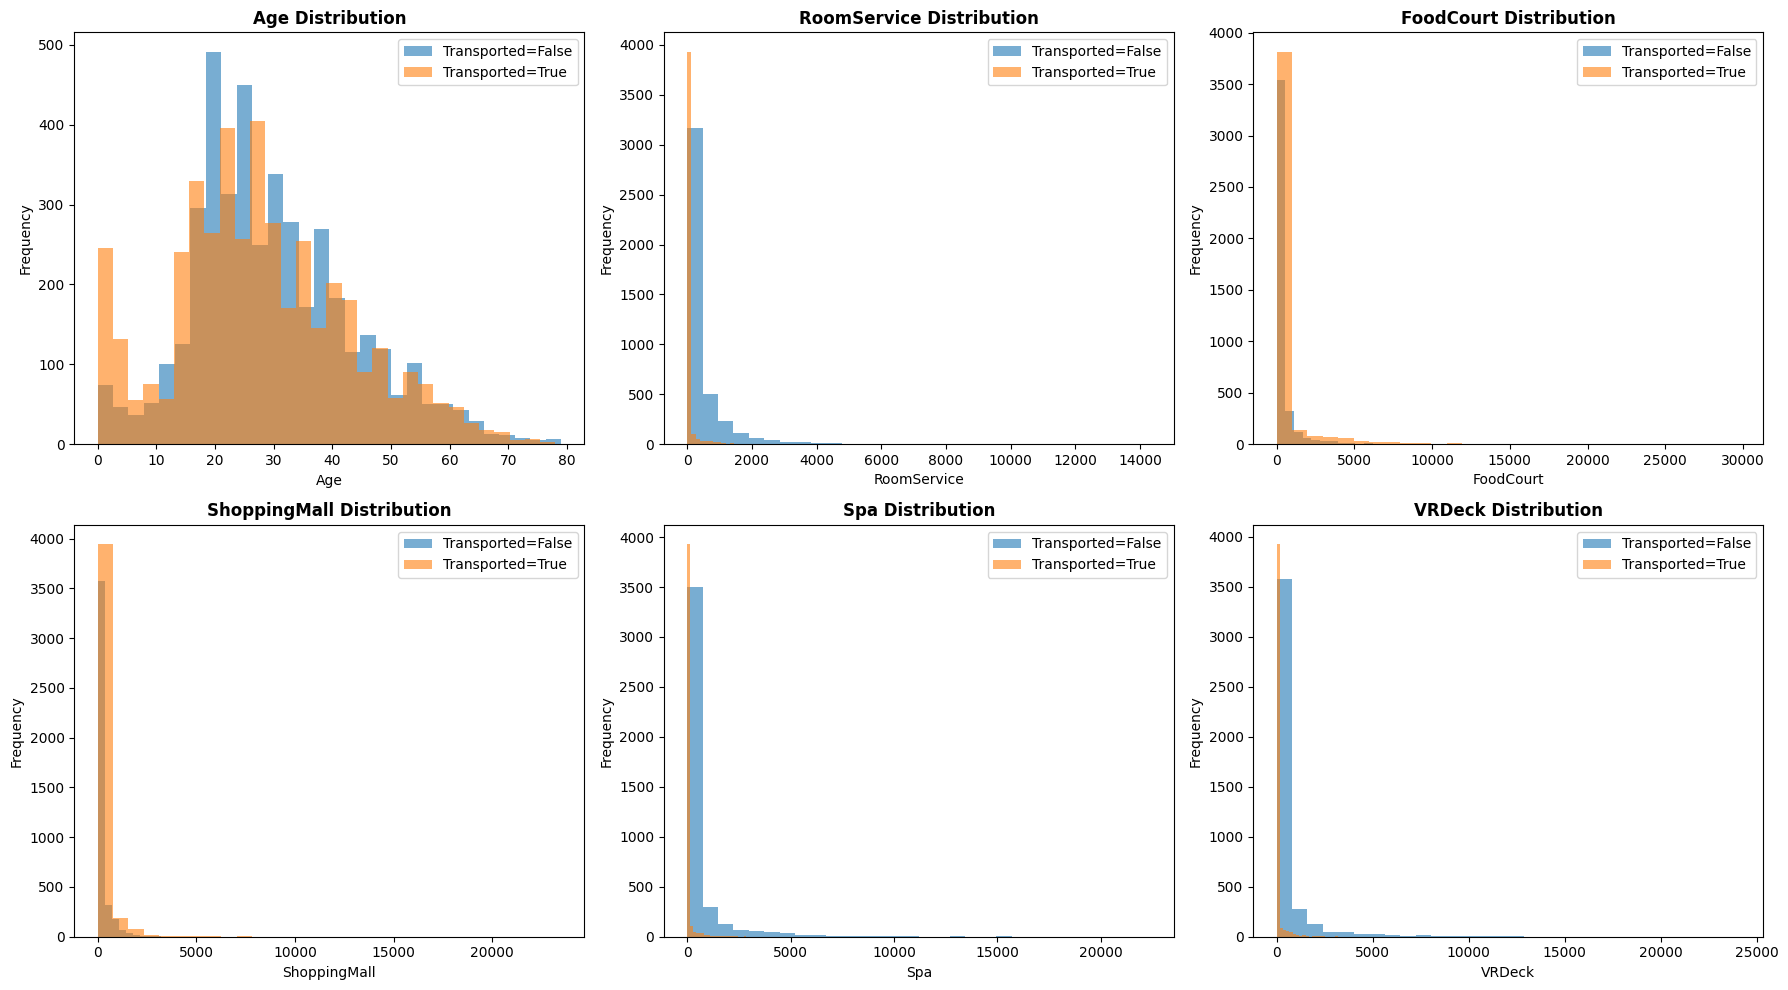

In [7]:
# Numerical features distribution
numerical_features = ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

for idx, col in enumerate(numerical_features):
    for transported in [False, True]:
        data = train_df[train_df['Transported'] == transported][col].dropna()
        axes[idx].hist(data, bins=30, alpha=0.6, label=f'Transported={transported}')
    
    axes[idx].set_title(f'{col} Distribution', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Frequency')
    axes[idx].legend()

plt.tight_layout()
plt.show()

## 4. Feature Engineering

In [8]:
def feature_engineering(df):
    """Apply comprehensive feature engineering"""
    df = df.copy()
    
    # Extract features from Cabin
    df['Deck'] = df['Cabin'].apply(lambda x: x.split('/')[0] if pd.notna(x) else 'Unknown')
    df['Cabin_num'] = df['Cabin'].apply(lambda x: x.split('/')[1] if pd.notna(x) else -1).astype(float)
    df['Side'] = df['Cabin'].apply(lambda x: x.split('/')[2] if pd.notna(x) else 'Unknown')
    
    # Extract group and individual from PassengerId
    df['Group'] = df['PassengerId'].apply(lambda x: x.split('_')[0])
    df['Group_size'] = df.groupby('Group')['Group'].transform('count')
    df['Solo'] = (df['Group_size'] == 1).astype(int)
    
    # Extract first and last name
    df['FirstName'] = df['Name'].apply(lambda x: x.split()[0] if pd.notna(x) else 'Unknown')
    df['LastName'] = df['Name'].apply(lambda x: x.split()[-1] if pd.notna(x) else 'Unknown')
    df['Family_size'] = df.groupby('LastName')['LastName'].transform('count')
    
    # Total spending features
    spending_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
    df['TotalSpending'] = df[spending_cols].sum(axis=1)
    df['HasSpending'] = (df['TotalSpending'] > 0).astype(int)
    df['NoSpending'] = (df['TotalSpending'] == 0).astype(int)
    
    # Spending ratios
    for col in spending_cols:
        df[f'{col}_ratio'] = df[col] / (df['TotalSpending'] + 1)
    
    # Age groups
    df['Age_group'] = pd.cut(df['Age'], bins=[0, 12, 18, 30, 50, 100], 
                              labels=['Child', 'Teen', 'Young_Adult', 'Adult', 'Senior'])
    df['Age_group'] = df['Age_group'].astype(str)
    
    # Missing value indicators
    df['Age_missing'] = df['Age'].isna().astype(int)
    df['CryoSleep_missing'] = df['CryoSleep'].isna().astype(int)
    
    return df

# Apply feature engineering
train_df = feature_engineering(train_df)

print(f"After feature engineering: {train_df.shape}")
print(f"\nNew features created:")
print(train_df.columns.tolist())

After feature engineering: (8693, 34)

New features created:
['PassengerId', 'HomePlanet', 'CryoSleep', 'Cabin', 'Destination', 'Age', 'VIP', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'Name', 'Transported', 'Deck', 'Cabin_num', 'Side', 'Group', 'Group_size', 'Solo', 'FirstName', 'LastName', 'Family_size', 'TotalSpending', 'HasSpending', 'NoSpending', 'RoomService_ratio', 'FoodCourt_ratio', 'ShoppingMall_ratio', 'Spa_ratio', 'VRDeck_ratio', 'Age_group', 'Age_missing', 'CryoSleep_missing']


## 5. Data Preprocessing

In [9]:
def preprocess_data(df, is_train=True):
    """Preprocess the data for modeling"""
    df = df.copy()
    
    # Define features to use
    categorical_features = ['HomePlanet', 'CryoSleep', 'Destination', 'VIP', 'Deck', 'Side', 'Age_group']
    numerical_features = ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck',
                         'Cabin_num', 'Group_size', 'Solo', 'Family_size', 'TotalSpending',
                         'HasSpending', 'NoSpending', 'Age_missing', 'CryoSleep_missing'] + \
                        [col for col in df.columns if '_ratio' in col]
    
    # Fill missing values
    for col in categorical_features:
        df[col] = df[col].fillna('Unknown')
    
    for col in numerical_features:
        if col in df.columns:
            df[col] = df[col].fillna(df[col].median())
    
    # Encode categorical features
    label_encoders = {}
    for col in categorical_features:
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col].astype(str))
        label_encoders[col] = le
    
    # Select features
    feature_columns = categorical_features + numerical_features
    X = df[feature_columns]
    
    if is_train:
        y = df['Transported'].astype(int)
        return X, y, feature_columns
    else:
        return X, feature_columns

# Preprocess training data
X, y, feature_columns = preprocess_data(train_df, is_train=True)

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nFeatures used: {len(feature_columns)}")
print(feature_columns)

Features shape: (8693, 27)
Target shape: (8693,)

Features used: 27
['HomePlanet', 'CryoSleep', 'Destination', 'VIP', 'Deck', 'Side', 'Age_group', 'Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'Cabin_num', 'Group_size', 'Solo', 'Family_size', 'TotalSpending', 'HasSpending', 'NoSpending', 'Age_missing', 'CryoSleep_missing', 'RoomService_ratio', 'FoodCourt_ratio', 'ShoppingMall_ratio', 'Spa_ratio', 'VRDeck_ratio']


In [10]:
# Split data for validation
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

print(f"Training set: {X_train.shape}")
print(f"Validation set: {X_val.shape}")
print(f"\nClass distribution in training:")
print(y_train.value_counts(normalize=True))

Training set: (6954, 27)
Validation set: (1739, 27)

Class distribution in training:
Transported
1    0.503595
0    0.496405
Name: proportion, dtype: float64


## 6. Baseline Models (No Optimization)

In [11]:
# Store results
baseline_results = {}

# XGBoost Baseline
print("Training XGBoost Baseline...")
xgb_baseline = xgb.XGBClassifier(random_state=RANDOM_STATE)
xgb_baseline.fit(X_train, y_train)
xgb_pred = xgb_baseline.predict(X_val)
xgb_acc = accuracy_score(y_val, xgb_pred)
baseline_results['XGBoost'] = xgb_acc
print(f"XGBoost Baseline Accuracy: {xgb_acc:.4f}\n")

# LightGBM Baseline
print("Training LightGBM Baseline...")
lgb_baseline = lgb.LGBMClassifier(random_state=RANDOM_STATE, verbose=-1)
lgb_baseline.fit(X_train, y_train)
lgb_pred = lgb_baseline.predict(X_val)
lgb_acc = accuracy_score(y_val, lgb_pred)
baseline_results['LightGBM'] = lgb_acc
print(f"LightGBM Baseline Accuracy: {lgb_acc:.4f}\n")

# Logistic Regression Baseline (Expected Worst Performer)
print("Training Logistic Regression Baseline...")
lr_baseline = LogisticRegression(random_state=RANDOM_STATE)
lr_baseline.fit(X_train, y_train)
lr_pred = lr_baseline.predict(X_val)
lr_acc = accuracy_score(y_val, lr_pred)
baseline_results['LogisticRegression'] = lr_acc
print(f"Logistic Regression Baseline Accuracy: {lr_acc:.4f}\n")

# Display results
baseline_df = pd.DataFrame.from_dict(baseline_results, orient='index', columns=['Accuracy'])
baseline_df = baseline_df.sort_values('Accuracy', ascending=False)
print("\n=== BASELINE RESULTS ===")
print(baseline_df)

Training XGBoost Baseline...
XGBoost Baseline Accuracy: 0.7993

Training LightGBM Baseline...
LightGBM Baseline Accuracy: 0.8108

Training Logistic Regression Baseline...
Logistic Regression Baseline Accuracy: 0.7706


=== BASELINE RESULTS ===
                    Accuracy
LightGBM            0.810811
XGBoost             0.799310
LogisticRegression  0.770558


## 7. Hyperparameter Optimization with Optuna

I'll optimize one models using Optuna with cross-validation.
**You have to optimize the other two**

In [12]:
# Define cross-validation strategy
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

### 7.1 Logistic Regression Optimization

In [13]:
def objective_lr(trial):
    """Optuna objective for Logistic Regression"""
    params = {
        'C': trial.suggest_float('C', 0.001, 100, log=True),
        'penalty': trial.suggest_categorical('penalty', ['l1', 'l2']),
        'solver': trial.suggest_categorical('solver', ['liblinear', 'saga']),
        'max_iter': trial.suggest_int('max_iter', 100, 2000),
        'random_state': RANDOM_STATE
    }
    
    # Handle incompatible penalty-solver combinations
    if params['solver'] == 'liblinear' and params['penalty'] not in ['l1', 'l2']:
        params['penalty'] = 'l2'
    
    model = LogisticRegression(**params)
    scores = cross_val_score(model, X, y, cv=cv, scoring='accuracy', n_jobs=-1)
    return scores.mean()

print("Optimizing Logistic Regression...")
from optuna.samplers import TPESampler

# Set a seed for reproducibility
sampler = TPESampler(seed=RANDOM_STATE)

study_lr = optuna.create_study(direction='maximize', study_name='logistic_regression_optimization', sampler=sampler)
study_lr.optimize(objective_lr, n_trials=30, show_progress_bar=True)

print(f"\nBest Logistic Regression CV Accuracy: {study_lr.best_value:.4f}")
print(f"Best parameters: {study_lr.best_params}")

[I 2026-03-12 17:19:35,464] A new study created in memory with name: logistic_regression_optimization


Optimizing Logistic Regression...


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2026-03-12 17:19:39,347] Trial 0 finished with value: 0.7890252125641299 and parameters: {'C': 0.0745934328572655, 'penalty': 'l1', 'solver': 'liblinear', 'max_iter': 396}. Best is trial 0 with value: 0.7890252125641299.
[I 2026-03-12 17:19:42,434] Trial 1 finished with value: 0.7780968123817572 and parameters: {'C': 0.0019517224641449498, 'penalty': 'l1', 'solver': 'liblinear', 'max_iter': 1943}. Best is trial 0 with value: 0.7890252125641299.
[I 2026-03-12 17:19:47,921] Trial 2 finished with value: 0.7814329227741563 and parameters: {'C': 14.528246637516036, 'penalty': 'l1', 'solver': 'saga', 'max_iter': 1097}. Best is trial 0 with value: 0.7890252125641299.
[I 2026-03-12 17:19:50,303] Trial 3 finished with value: 0.7813179803214816 and parameters: {'C': 0.14445251022763064, 'penalty': 'l2', 'solver': 'saga', 'max_iter': 796}. Best is trial 0 with value: 0.7890252125641299.
[I 2026-03-12 17:19:51,468] Trial 4 finished with value: 0.7814327904282119 and parameters: {'C': 0.19069966

## 8. Train Final Models with Best Parameters

In [14]:
# Train final models on full training data
print("Training final models with optimized parameters...\n")

# Logistic Regression
print("Training Logistic Regression...")
lr_final = LogisticRegression(**study_lr.best_params, random_state=RANDOM_STATE)
lr_final.fit(X, y)

print("\nModel trained successfully!")

Training final models with optimized parameters...

Training Logistic Regression...

Model trained successfully!


## 13. Create Submission File

In [15]:
# Load test data
test_df = pd.read_csv('test.csv')
test_passenger_ids = test_df['PassengerId'].copy()

# Preprocess
test_df = feature_engineering(test_df)
X_test, _ = preprocess_data(test_df, is_train=False)

# Predict
predictions = lr_final.predict(X_test)

# Create submission
submission = pd.DataFrame({
    'PassengerId': test_passenger_ids,
    'Transported': predictions.astype(bool)
})

# Save
submission.to_csv('submission.csv', index=False)